<a href="https://colab.research.google.com/github/harrshat/MachineLearningReferenceDocs/blob/main/SVM%20Kernels%20Implementation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [16]:
x= np.linspace(-5.0,5.0,100)
y=np.sqrt(10**2 - x**2)
y=np.hstack([y,-y]) #alt- np.concatenate
x=np.hstack([x,-x])

In [17]:
x

array([-5.        , -4.8989899 , -4.7979798 , -4.6969697 , -4.5959596 ,
       -4.49494949, -4.39393939, -4.29292929, -4.19191919, -4.09090909,
       -3.98989899, -3.88888889, -3.78787879, -3.68686869, -3.58585859,
       -3.48484848, -3.38383838, -3.28282828, -3.18181818, -3.08080808,
       -2.97979798, -2.87878788, -2.77777778, -2.67676768, -2.57575758,
       -2.47474747, -2.37373737, -2.27272727, -2.17171717, -2.07070707,
       -1.96969697, -1.86868687, -1.76767677, -1.66666667, -1.56565657,
       -1.46464646, -1.36363636, -1.26262626, -1.16161616, -1.06060606,
       -0.95959596, -0.85858586, -0.75757576, -0.65656566, -0.55555556,
       -0.45454545, -0.35353535, -0.25252525, -0.15151515, -0.05050505,
        0.05050505,  0.15151515,  0.25252525,  0.35353535,  0.45454545,
        0.55555556,  0.65656566,  0.75757576,  0.85858586,  0.95959596,
        1.06060606,  1.16161616,  1.26262626,  1.36363636,  1.46464646,
        1.56565657,  1.66666667,  1.76767677,  1.86868687,  1.96

In [18]:
y

array([ 8.66025404,  8.71779204,  8.77378994,  8.82827705,  8.88128118,
        8.93282873,  8.98294476,  9.03165312,  9.07897646,  9.12493632,
        9.16955321,  9.21284664,  9.25483518,  9.29553652,  9.3349675 ,
        9.37314414,  9.41008171,  9.44579475,  9.4802971 ,  9.51360192,
        9.54572176,  9.57666854,  9.60645359,  9.63508769,  9.66258107,
        9.68894344,  9.714184  ,  9.73831149,  9.76133416,  9.7832598 ,
        9.80409577,  9.82384901,  9.84252604,  9.86013297,  9.87667553,
        9.89215905,  9.90658851,  9.91996849,  9.93230325,  9.94359667,
        9.9538523 ,  9.96307334,  9.97126266,  9.9784228 ,  9.98455598,
        9.98966408,  9.99374868,  9.99681104,  9.99885209,  9.99987246,
        9.99987246,  9.99885209,  9.99681104,  9.99374868,  9.98966408,
        9.98455598,  9.9784228 ,  9.97126266,  9.96307334,  9.9538523 ,
        9.94359667,  9.93230325,  9.91996849,  9.90658851,  9.89215905,
        9.87667553,  9.86013297,  9.84252604,  9.82384901,  9.80

In [25]:
x1= np.linspace(-5.0,5.0,100)
y1=np.sqrt(5**2 - x1**2)
y1=np.hstack([y1,-y1])
x1=np.hstack([x1,-x1])

In [26]:
x1.shape

(200,)

In [27]:
y1.shape

(200,)

In [28]:
x.shape

(200,)

In [29]:
y.shape

(200,)

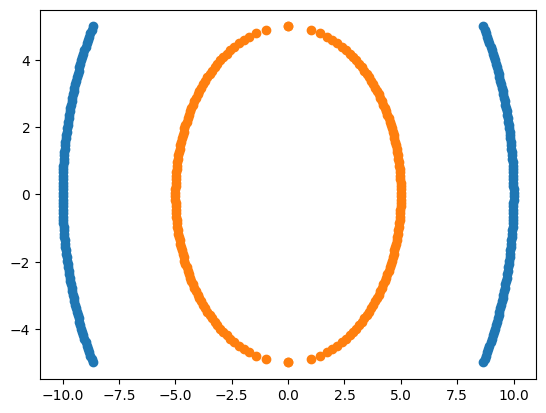

In [30]:
plt.scatter(y,x)
plt.scatter(y1,x1)


# In this, a 'best fit line' can't be drawn


In [34]:
np.vstack([x,y]).shape

(2, 200)

# v stack
a = np.array([1, 2, 3])
b = np.array([4, 5, 6])

Use numpy.vstack() to stack them vertically
c = np.vstack((a,b))
print(c)

Output:
[[1 2 3]
 [4 5 6]] --length-2

In [38]:
df1=pd.DataFrame(np.vstack([y,x]).T,columns=['X1','X2'])

In [39]:
df1.head(5)

,X1,X2
0,8.660254,-5.00000
1,8.717792,-4.89899
2,8.773790,-4.79798
3,8.828277,-4.69697
4,8.881281,-4.59596


In [40]:
df2=pd.DataFrame(np.vstack([y1,x1]).T,columns=['X1','X2'])
df2.head(5)

,X1,X2
0,0.000000,-5.00000
1,0.999949,-4.89899
2,1.406908,-4.79798
3,1.714198,-4.69697
4,1.969049,-4.59596


In [43]:
df1['Y']=0
df2['Y']=1
df = pd.concat([df1, df2], ignore_index=True)

         X1       X2  Y
0  8.660254 -5.00000  0
1  8.717792 -4.89899  0
2  8.773790 -4.79798  0
3  8.828277 -4.69697  0
4  8.881281 -4.59596  0


In [44]:
df.head(5)

,X1,X2,Y
0,8.660254,-5.00000,0
1,8.717792,-4.89899,0
2,8.773790,-4.79798,0
3,8.828277,-4.69697,0
4,8.881281,-4.59596,0


In [45]:
df['Y'].value_counts()

,count
Y,
0,200
1,200


In [52]:
# Dependent and independent features
X=df[['X1', 'X2']]
y=df['Y']

In [53]:
X.shape

(400, 2)

In [54]:
y.shape

(400,)

In [55]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

# Polynomial Kernel

In [58]:
df['X1_squared']=df['X1']**2
df['X2_squared']=df['X2']**2

In [60]:
df.head(3)

,X1,X2,Y,X1_squared,X2_squared
0,8.660254,-5.00000,0,75.000000,25.000000
1,8.717792,-4.89899,0,75.999898,24.000102
2,8.773790,-4.79798,0,76.979390,23.020610


In [61]:
df['X1*X2']=df['X1']*df['X2']

In [62]:
df.head(3)

,X1,X2,Y,X1_squared,X2_squared,X1*X2
0,8.660254,-5.00000,0,75.000000,25.000000,-43.301270
1,8.717792,-4.89899,0,75.999898,24.000102,-42.708375
2,8.773790,-4.79798,0,76.979390,23.020610,-42.096467


In [63]:
df.columns

Index(['X1', 'X2', 'Y', 'X1_squared', 'X2_squared', 'X1*X2'], dtype='object')

In [64]:
X=df[['X1', 'X2', 'X1*X2', 'X1_squared', 'X2_squared']]
y=df['Y']

In [65]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

In [66]:
import plotly.express as px

In [67]:
fig = px.scatter_3d(df,x='X1',y='X2',z='X1*X2',color='Y')

In [68]:
fig.show()

In [69]:
fig1 = px.scatter_3d(df,x='X1_squared',y='X2_squared',z='X1*X2',color='Y')
fig1.show()

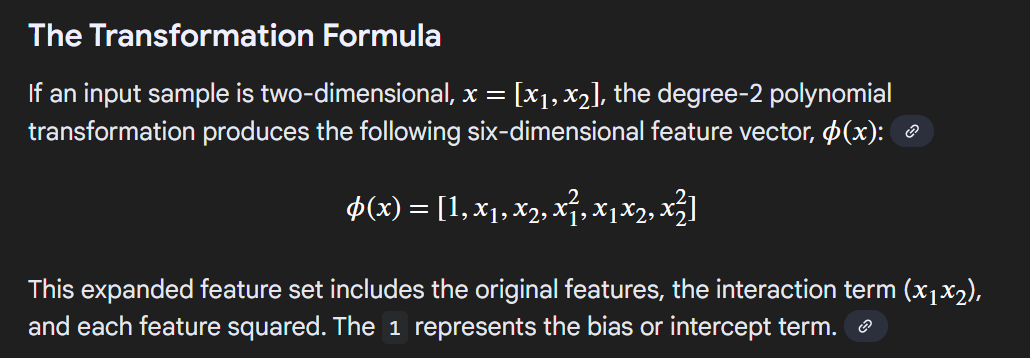

In [70]:
from sklearn.svm import SVC

In [79]:
svc=SVC(kernel='linear')

In [80]:
svc.fit(X_train,y_train)
y_pred=svc.predict(X_test)

In [81]:
from sklearn.metrics import confusion_matrix,classification_report

In [82]:
print("Classification Report")
print(classification_report(y_test,y_pred))

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        52
           1       1.00      1.00      1.00        48

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



In [83]:
print("Confusion Matrix:")
print(confusion_matrix(y_test,y_pred))

Confusion Matrix:
[[52  0]
 [ 0 48]]


In [84]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test,y_pred))

1.0
